In [1]:
import os
import sys
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Füge das Projekt-Hauptverzeichnis (zwei Ebenen höher: '../..') hinzu
sys.path.append(os.path.abspath(os.path.join('../..')))
sys.path.append(os.path.abspath(os.path.join('..')))  

# Jetzt über das "python"-Package importieren
from python.evaluation.metrics import calculate_pretreatment_fit, calculate_ground_truth_effect
from python.evaluation.visualization import plot_fit_joint_contour, plot_transport_comparison, plot_fit_copula, plot_fit_cdf, plot_fit_density
from python.tea import disco_tea

In [11]:
# load fits
dico_energy = joblib.load('results/fits/real_data/medicaid_v2_30_2017_energy.pkl')
dico_mixture = joblib.load('results/fits/real_data/medicaid_30_2017_mixture.pkl')
dico_tangential = joblib.load('results/fits/real_data/medicaid_v2_30_2017_tangential.pkl')
dico_swasserstein = joblib.load('results/fits/real_data/medicaid_30_2017_swasserstein.pkl')

In [12]:
plot_fit_joint_contour(dico_tangential, period=10)

KeyError: 10

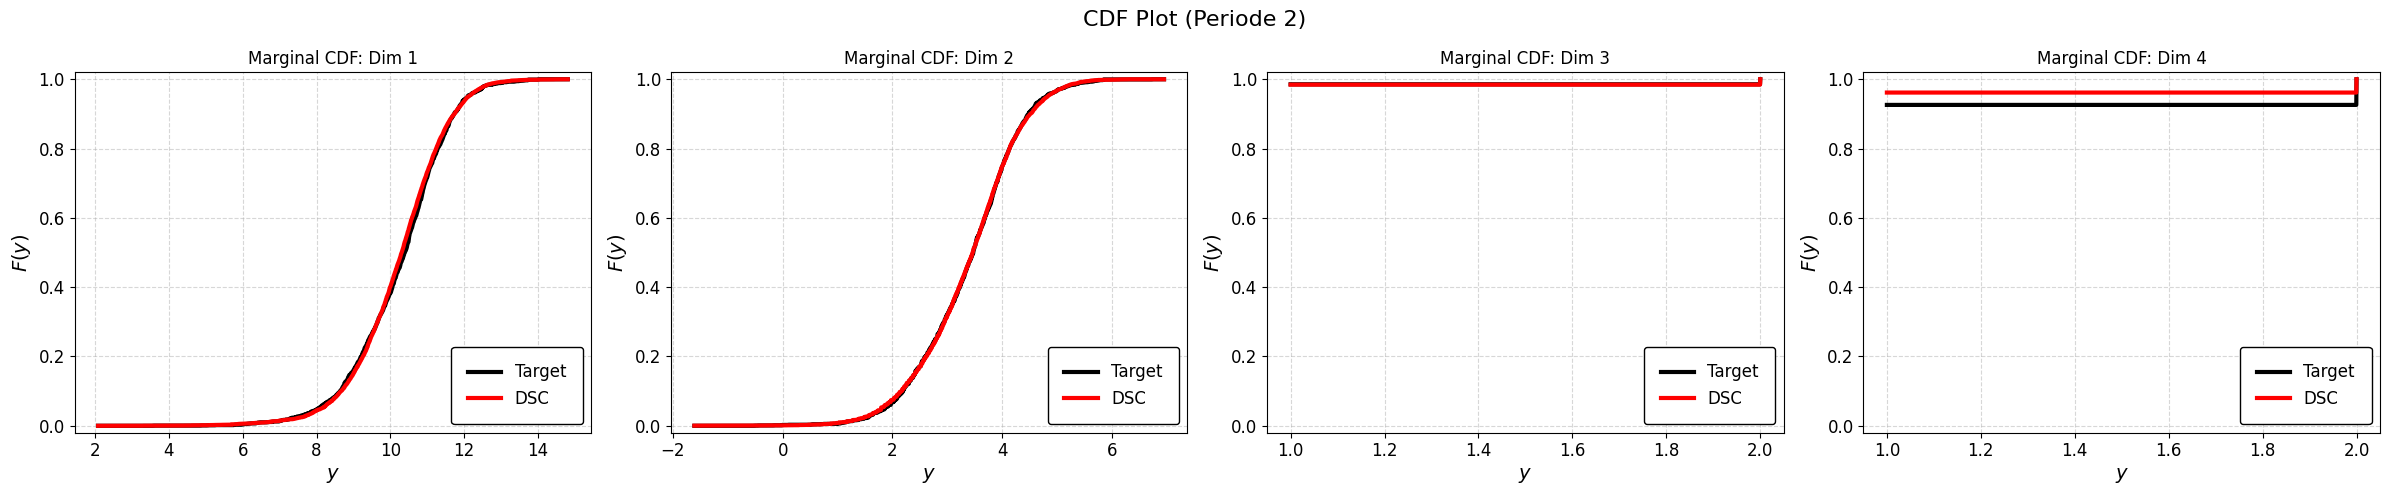

In [18]:
plot_fit_cdf(dico_tangential, period=2)

In [5]:
plot_fit_copula(dico_energy, period=7)

Joint Plot wird nur für 2D Daten unterstützt.


In [14]:
import copy
dico_test = copy.deepcopy(dico_energy)
dico_test.weights = np.array(
    [
        0.184,
        0.0,
        0.0,
        0.0,
        0.174,
        0.0,
        0.01,
        0.513,
        0.0,
        0.0,
        0.119,
        0.0
    ]
)
np.round(dico_tangential.weights, decimals=3)

array([ 0.187, -0.   , -0.   ,  0.047,  0.259,  0.   , -0.   ,  0.364,
       -0.   ,  0.   ,  0.124,  0.019])

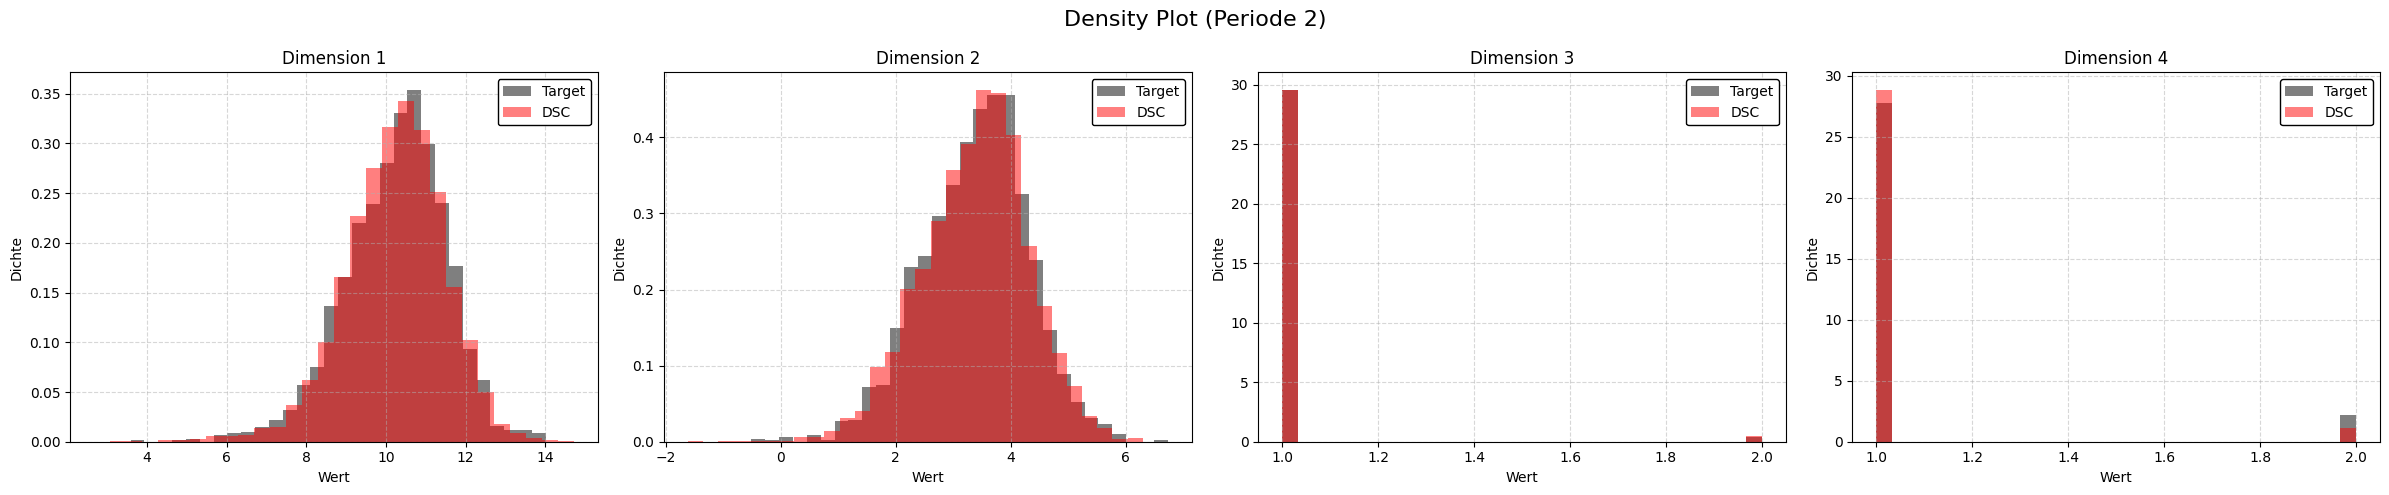

In [17]:
plot_fit_density(dico_tangential, period=2)

In [15]:
pd.Series(dico_test.weights, index = dico_test.control_ids)

1     0.184
12    0.000
13    0.000
20    0.000
28    0.174
37    0.000
45    0.010
46    0.513
47    0.000
48    0.000
55    0.119
56    0.000
dtype: float64

In [7]:
effect_energy = joblib.load('results/effects/medicaid_30_2017_energy_teas.pkl')


# Hybrid: Weigths hitrates

In [8]:
from data import get_hybrid_data

weigths = []

for seed in range(25):
    weigths.append(get_hybrid_data('data/datasets/medicaid.csv', seed=seed)[1])

In [45]:
method = 'swasserstein'

fitted_weigths_swasserstein = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_swasserstein.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'tangential'

fitted_weigths_tangential = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_tangential.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'mixture'

fitted_weigths_mixture = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_mixture.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'energy'

fitted_weigths_energy = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_energy.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

df_swasserstein = pd.DataFrame(fitted_weigths_swasserstein)
df_tangential = pd.DataFrame(fitted_weigths_tangential)
df_mixture = pd.DataFrame(fitted_weigths_mixture)
df_energy = pd.DataFrame(fitted_weigths_energy)

=== Sparsity Vergleich (Methode: energy) ===
Durchschnittliche Anzahl echter Spender (w > 0.001): 5.0
Durchschnittliche Anzahl geschätzter Spender (w > 0.001): 12.5



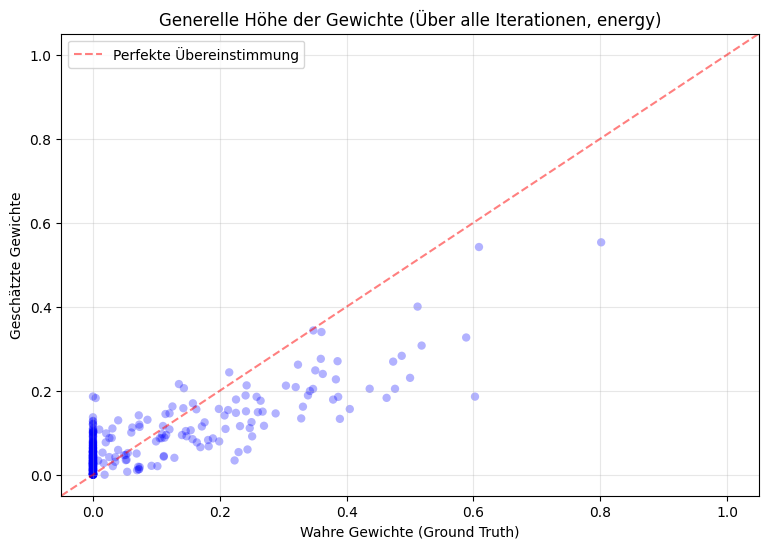

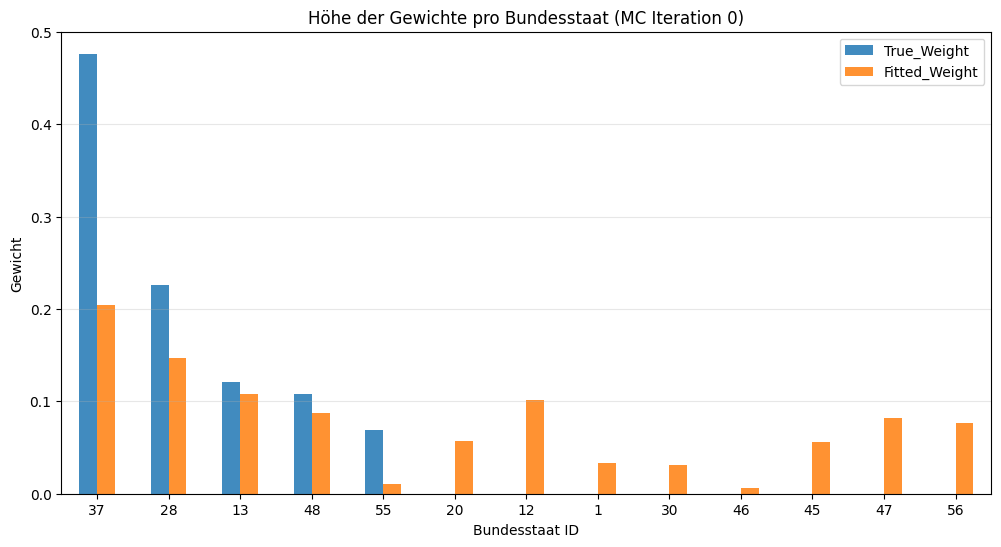

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fitted_weigths = fitted_weigths_energy

# Schwellenwert für Sparsity
threshold = 1e-3

true_non_zeros_list = []
fitted_non_zeros_list = []

all_true_weights = []
all_fitted_weights = []

# 1. Iteriere über alle 25 MC Durchläufe aus deinen geladenen Listen
for mc in range(len(weigths)):
    true_dict = weigths[mc]
    fitted_dict = fitted_weigths[mc]
    
    mc_true_w = []
    mc_fitted_w = []
    
    # State-IDs aus den wahren Gewichten abrufen
    for state_id in true_dict.keys():
        t_w = true_dict.get(state_id, 0.0)
        f_w = fitted_dict.get(state_id, 0.0)
        
        mc_true_w.append(t_w)
        mc_fitted_w.append(f_w)
        
        all_true_weights.append(t_w)
        all_fitted_weights.append(f_w)
        
    true_non_zeros_list.append(sum(w > threshold for w in mc_true_w))
    fitted_non_zeros_list.append(sum(w > threshold for w in mc_fitted_w))

# 2. Sparsity Analyse (Durchschnitt über alle MC Iterationen)
avg_true_sparsity = np.mean(true_non_zeros_list)
avg_fitted_sparsity = np.mean(fitted_non_zeros_list)

print(f"=== Sparsity Vergleich (Methode: {method}) ===")
print(f"Durchschnittliche Anzahl echter Spender (w > {threshold}): {avg_true_sparsity:.1f}")
print(f"Durchschnittliche Anzahl geschätzter Spender (w > {threshold}): {avg_fitted_sparsity:.1f}\n")

# 3. Visualisierung: Original vs Neuer Fit (Generelle Höhe)
plt.figure(figsize=(9, 6))
# 45-Grad-Linie (Perfekter Match)
plt.plot([-0.05, 1.05], [-0.05, 1.05], 'r--', alpha=0.5, label='Perfekte Übereinstimmung')

# Wir plotten alle Gewichte aus allen Iterationen
plt.scatter(all_true_weights, all_fitted_weights, alpha=0.3, color='b', edgecolor='none')

plt.title(f'Generelle Höhe der Gewichte (Über alle Iterationen, {method})')
plt.xlabel('Wahre Gewichte (Ground Truth)')
plt.ylabel('Geschätzte Gewichte')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Barplot für EINE zufällige Iteration (z.B. Iteration 0), um es sich konkret anzusehen
mc_plot = 0
df_single_mc = pd.DataFrame({
    'State_ID': list(weigths[mc_plot].keys()),
    'True_Weight': [weigths[mc_plot].get(k, 0.0) for k in weigths[mc_plot].keys()],
    'Fitted_Weight': [fitted_weigths[mc_plot].get(k, 0.0) for k in weigths[mc_plot].keys()]
})

# Nur relevante Spender filtern
df_filtered = df_single_mc[(df_single_mc['True_Weight'] > threshold) | (df_single_mc['Fitted_Weight'] > threshold)].copy()
df_filtered.sort_values(by='True_Weight', ascending=False, inplace=True)

df_filtered.plot(x='State_ID', y=['True_Weight', 'Fitted_Weight'], kind='bar', figsize=(12, 6), alpha=0.85)
plt.title(f'Höhe der Gewichte pro Bundesstaat (MC Iteration {mc_plot})')
plt.ylabel('Gewicht')
plt.xlabel('Bundesstaat ID')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3) 
plt.legend()
plt.show()


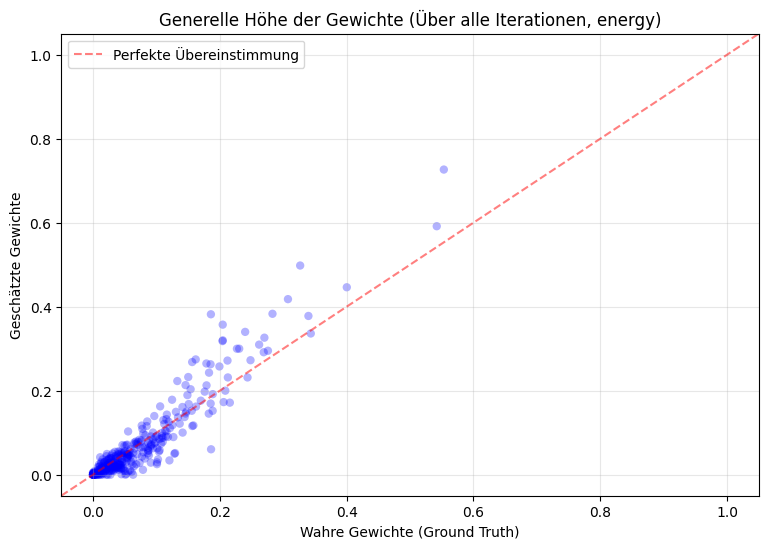

In [49]:
# 3. Visualisierung: Original vs Neuer Fit (Generelle Höhe)
plt.figure(figsize=(9, 6))
# 45-Grad-Linie (Perfekter Match)
plt.plot([-0.05, 1.05], [-0.05, 1.05], 'r--', alpha=0.5, label='Perfekte Übereinstimmung')

# Wir plotten alle Gewichte aus allen Iterationen
plt.scatter(np.reshape(df_energy.values, (1,-1))
            , np.reshape(df_mixture.values, (1,-1)),
             alpha=0.3, color='b', edgecolor='none')

plt.title(f'Generelle Höhe der Gewichte (Über alle Iterationen, {method})')
plt.xlabel('Wahre Gewichte (Ground Truth)')
plt.ylabel('Geschätzte Gewichte')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()